##### ***GoogLeNet***
###### GoogLeNet吸收了NiN中串联网络的思想，并在此基础上做了改进，由于之前的一众神经网络架构的卷积核大小都不同，从1x1到11x11都有，所以GoogLeNet使用了不同大小的卷积核进行组合，从而提高了模型的效率，除此之外引入了一个新的模块：Inception块。
##### ***Inception 块***
###### Inception块由4条并行路径组成，前三条路径分别是1x1卷积层、3x3卷积层和5x5卷积层，从不同空间大小中提取信息。中间两条路径在输入上执行1x1卷积层来减少通道数，从而适当降低模型的复杂性。第四条路径是3x3最大池化层接上1x1卷积层。最后将四条路径的输出在通道维度上堆叠。
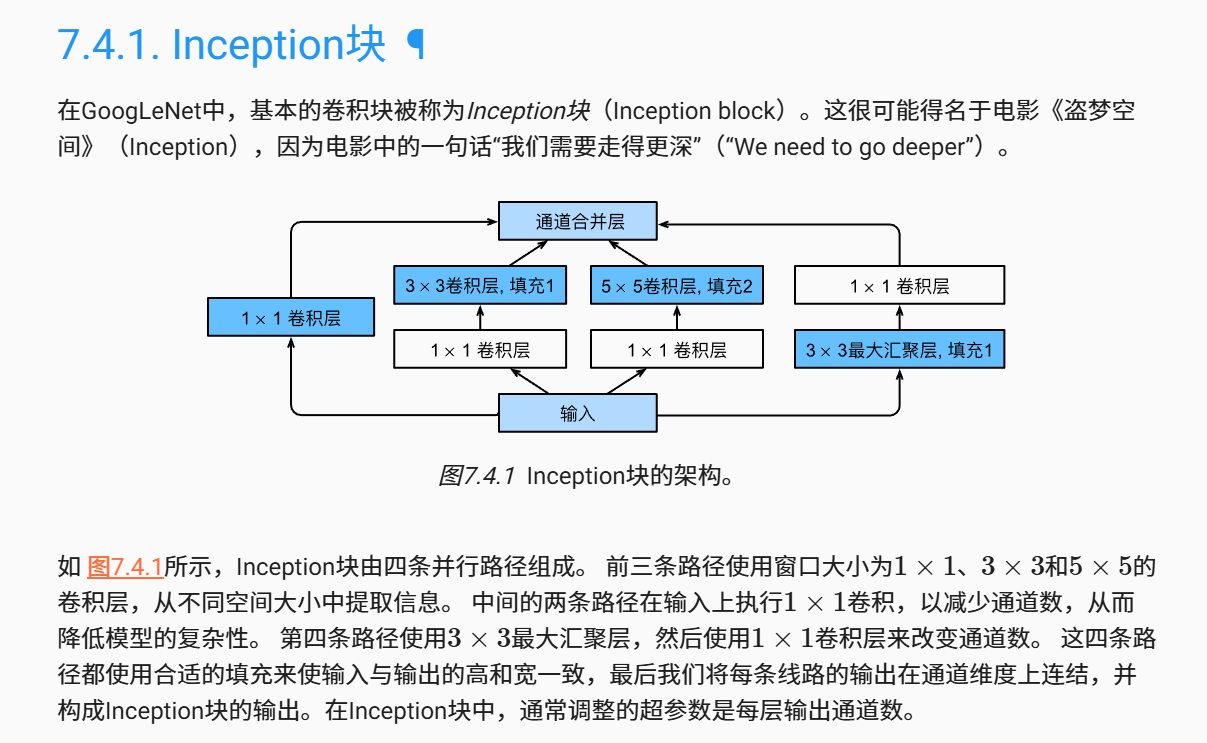

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

class Inception(nn.Module):
    #c1-c4是四条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 线路2，1x1卷积层后接3x3卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        # 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        # 线路4，3x3最大池化层后接1x1卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)
    
    def forward(self, x):
        p1 = nn.functional.relu(self.p1_1(x))
        p2 = nn.functional.relu(self.p2_2(nn.functional.relu(self.p2_1(x))))
        p3 = nn.functional.relu(self.p3_2(nn.functional.relu(self.p3_1(x))))
        p4 = nn.functional.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上堆叠
        return torch.cat((p1, p2, p3, p4), dim=1)

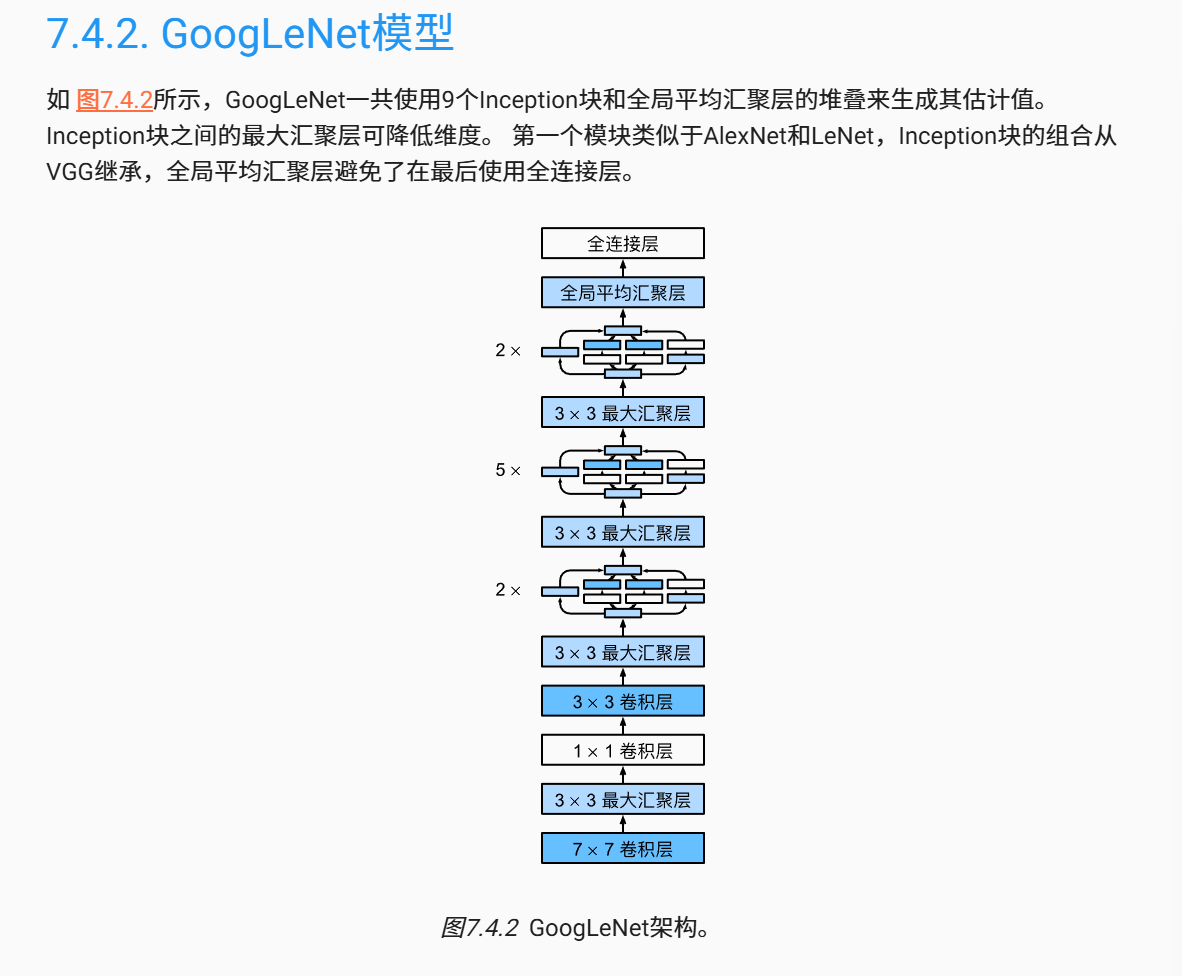

In [2]:
# 第一个模块用了64个通道、7x7卷积层，步幅为2，填充为3，
# 然后是3x3最大池化层，步幅为2，填充为1。
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

In [3]:
# 第二个模块用了64个通道、1x1卷积层，然后是3x3卷积层，步幅为1，填充为1。
# 然后是3x3最大池化层，步幅为2，填充为1。
b2 = nn.Sequential(
    nn.Conv2d(64, 64, kernel_size=1),
    nn.ReLU(),
    nn.Conv2d(64, 192, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

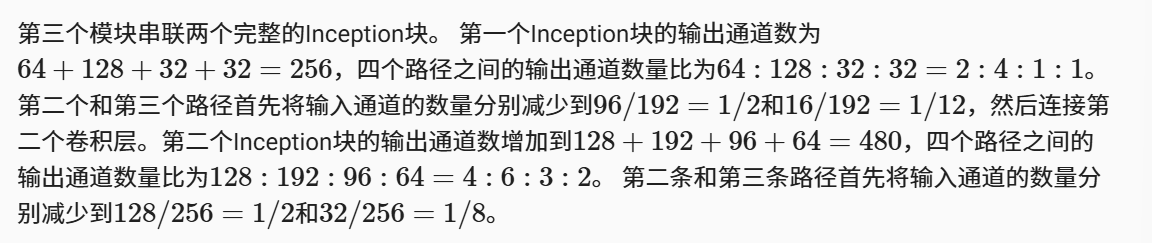

In [4]:
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                   Inception(256, 128, (128, 192), (32, 96), 64),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

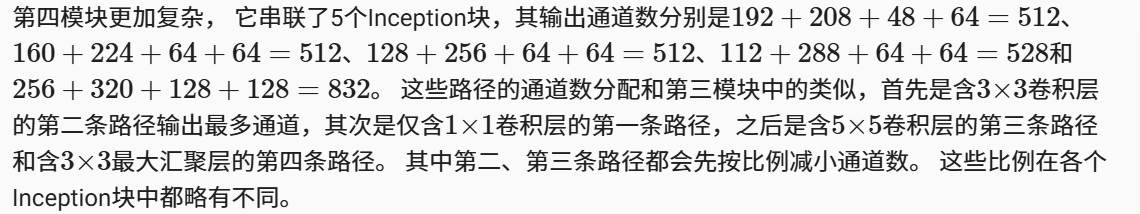

In [5]:
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                   Inception(512, 160, (112, 224), (24, 64), 64),
                   Inception(512, 128, (128, 256), (24, 64), 64),
                   Inception(512, 112, (144, 288), (32, 64), 64),
                   Inception(528, 256, (160, 320), (32, 128), 128),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

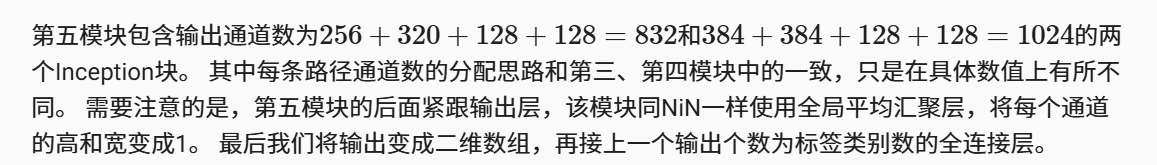

In [6]:
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                   Inception(832, 384, (192, 384), (48, 128), 128),
                   nn.AdaptiveAvgPool2d((1,1)),
                   nn.Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))

In [7]:
X = torch.rand(size=(1, 1, 96, 96))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


KeyboardInterrupt: 

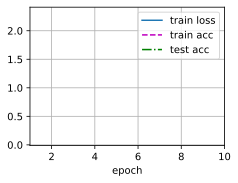

In [8]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

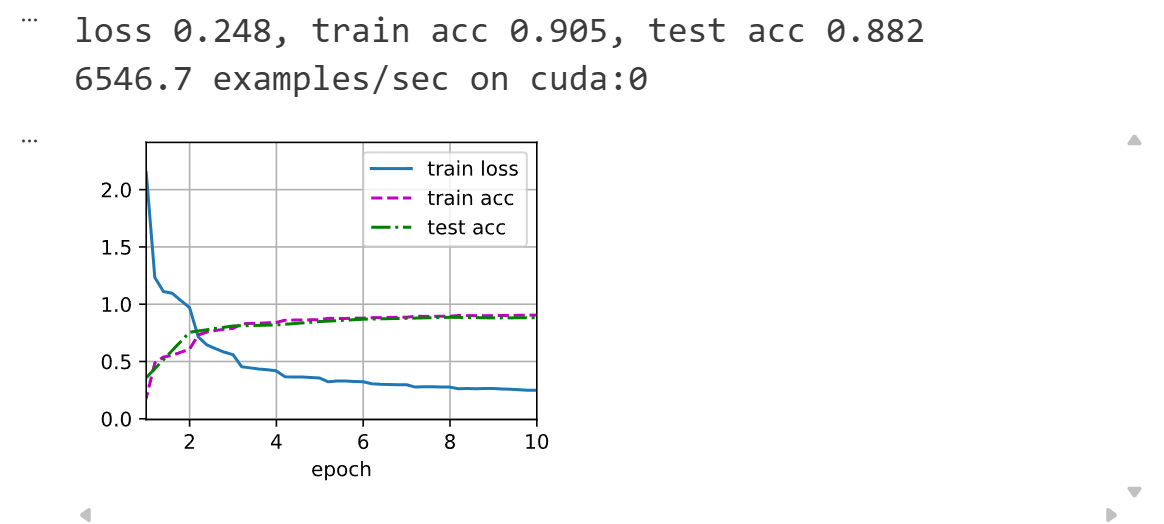